In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import mnist
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train[:10000]
y_train = y_train[:10000]
X_test = X_test[:300]
y_test = y_test[:300]

print(f"Dataset shape: {X_train.shape}")
print(f"Testing Data shape: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: (10000, 28, 28)
Testing Data shape: (300, 28, 28)


In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened shape: {X_train_flat.shape}")

Flattened shape: (10000, 784)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

In [ ]:
pca = PCA(n_components=80)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"PCA reduced shape: {X_train_pca.shape}")

PCA reduced shape: (10000, 80)


In [ ]:
print("Eigenvalues:")
print(pca.explained_variance_)
print("\nEigenvectors (first 5 components):")
print(pca.components_[:5])

Eigenvalues:
[41.48764824 29.38775657 27.23079609 20.77667703 18.20599965 15.87820262
 13.90587661 12.82867769 11.24979688 10.14558462  9.89371145  8.31712489
  8.08405314  7.78606296  7.72808281  7.30167641  6.91166113  6.62848044
  6.44124061  6.37191546  6.15420975  5.92516619  5.73073266  5.51806474
  5.3400473   5.22047599  5.07780002  4.75760224  4.70154727  4.51585746
  4.49638859  4.27359227  4.19703999  4.15606918  4.07902064  3.97472275
  3.94574525  3.78250493  3.73495595  3.6344533   3.55020633  3.44211907
  3.42064065  3.33297635  3.21360373  3.14156081  3.1186668   3.05549843
  3.01916682  2.96906693  2.92559245  2.84480832  2.7986622   2.7362665
  2.70795348  2.69041476  2.63064753  2.59460577  2.58880566  2.48140712
  2.47024644  2.43777571  2.41619376  2.37759701  2.34076041  2.3214537
  2.26382839  2.2471674   2.21146975  2.19621313  2.13746991  2.11349115
  2.10993319  2.08272844  2.06253442  2.0467129   2.04343183  2.01100012
  2.00301663  1.98856044]

Eigenvectors 

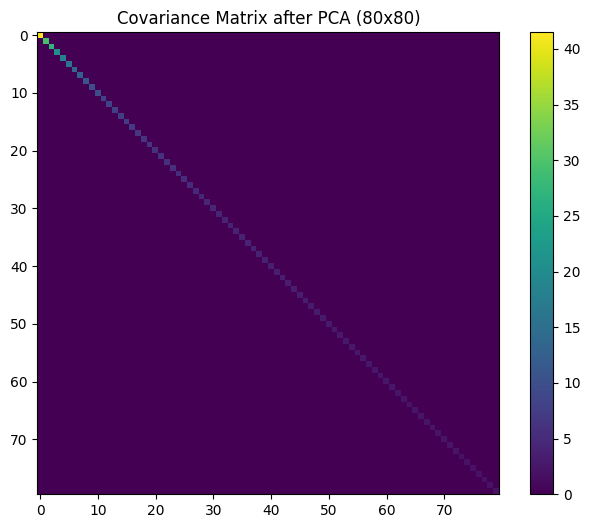

In [ ]:
cov_matrix = np.cov(X_train_pca.T)
plt.figure(figsize=(8, 6))
plt.imshow(cov_matrix, cmap='viridis')
plt.title("Covariance Matrix after PCA (80x80)")
plt.colorbar()
plt.show()

In [ ]:
X_train_reconstructed = pca.inverse_transform(X_train_pca)
X_train_reconstructed = X_train_reconstructed.reshape(-1, 28, 28)

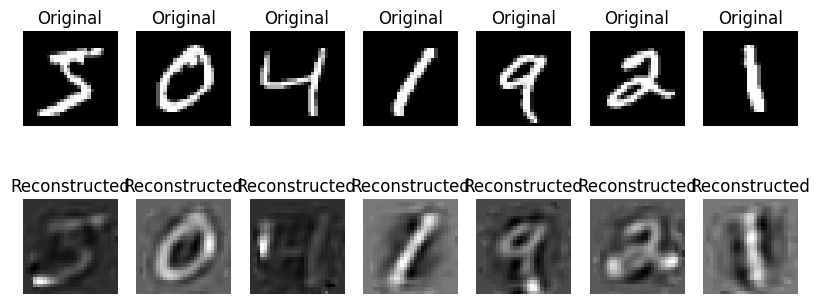

In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(10, 4))
for i in range(7):
    # Original
    axes[0, i].imshow(X_train[i], cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')
    # Reconstructed
    axes[1, i].imshow(X_train_reconstructed[i], cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')
plt.show()

In [ ]:
total_variance = np.sum(pca.explained_variance_ratio_)
print(f"Total Variance Retained: {total_variance:.2f}")

Total Variance Retained: 0.70


In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy after PCA: {accuracy:.2f}")
print(f"Model Accuracy after PCA: {accuracy * 100:.2f}%")

Model Accuracy after PCA: 0.94
Model Accuracy after PCA: 93.67%
